# Raw Data Inspection

Visualisation of the raw (uncorrected) complex visibility $V(\nu, h)$ from all observation chips, plotted against hour angle. Each chip is shown in a distinct colour to reveal gain variations, temporal gaps, and the fringe structure before any preprocessing.

The IF chain configuration (sky band $10.29\text{–}10.54\;\mathrm{GHz}$, 250 MHz total bandwidth, $N_{\rm FFT} = 2048$, yielding 1024 output channels of $\Delta\nu = 244\;\mathrm{kHz}$ each) and the bad-channel list `(0, 256, 512, 768)` (DC bin and FPGA pipeline harmonics at multiples of 256) are documented in the [AY 121 Lab 3 manual](../REFERENCES.md) (`[AY121-Lab3]`).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    PLOT_BAND_GHZ,
    BAD_CHANNELS,
    load_processed_sun_chip_series,
    # plotting
    NEUTRAL_COLOR,
    LW_FINE, LW_LIGHT,
    ALPHA_EXTRA_LIGHT,
    TEXTWIDTH_IN, TICK_SIZE,
)
from plotters import plot_raw_visibility_4panel, plot_amplitude_spectrum, plot_observation_timeline

COMPONENT_COLORS = [f"C{i}" for i in range(10)]

%matplotlib inline
print("Imports OK.")

Imports OK.


/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# --- Load data ---
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
chip_data = load_processed_sun_chip_series(chip_paths)

captures    = chip_data.captures
corr_raw    = captures.corr           # (N_cap, N_CH) complex — raw visibility
ha_deg_arr  = chip_data.ha_deg        # (N_cap,) hour angle in degrees
F_SKY_GHZ   = chip_data.f_sky_ghz    # (N_CH,)
chip_slices = chip_data.chip_slices
N_chips     = len(chip_slices)

# Analysis band mask (good channels inside the IF passband)
band_mask = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
for bc in BAD_CHANNELS:
    band_mask[bc] = False

# Band-averaged raw visibility per capture
corr_band = corr_raw[:, band_mask]   # (N_cap, N_band_ch) complex

print(f"Captures: {corr_raw.shape[0]},  Channels: {corr_raw.shape[1]}")
print(f"Analysis band: {PLOT_BAND_GHZ[0]:.3f}–{PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Chips: {N_chips}  ({[sl.stop - sl.start for sl in chip_slices]} captures)")

Captures: 8226,  Channels: 1024
Analysis band: 10.415–10.485 GHz  (285 channels)
Chips: 3  ([5514, 403, 2309] captures)


## Raw visibility vs hour angle (representative channel)

Each panel shows the raw complex visibility at a single representative channel near the band centre, as a function of hour angle. Chips are overlaid in different colours. No DC correction has been applied — the DC pedestal is visible in the real part as a slowly-varying offset from zero.

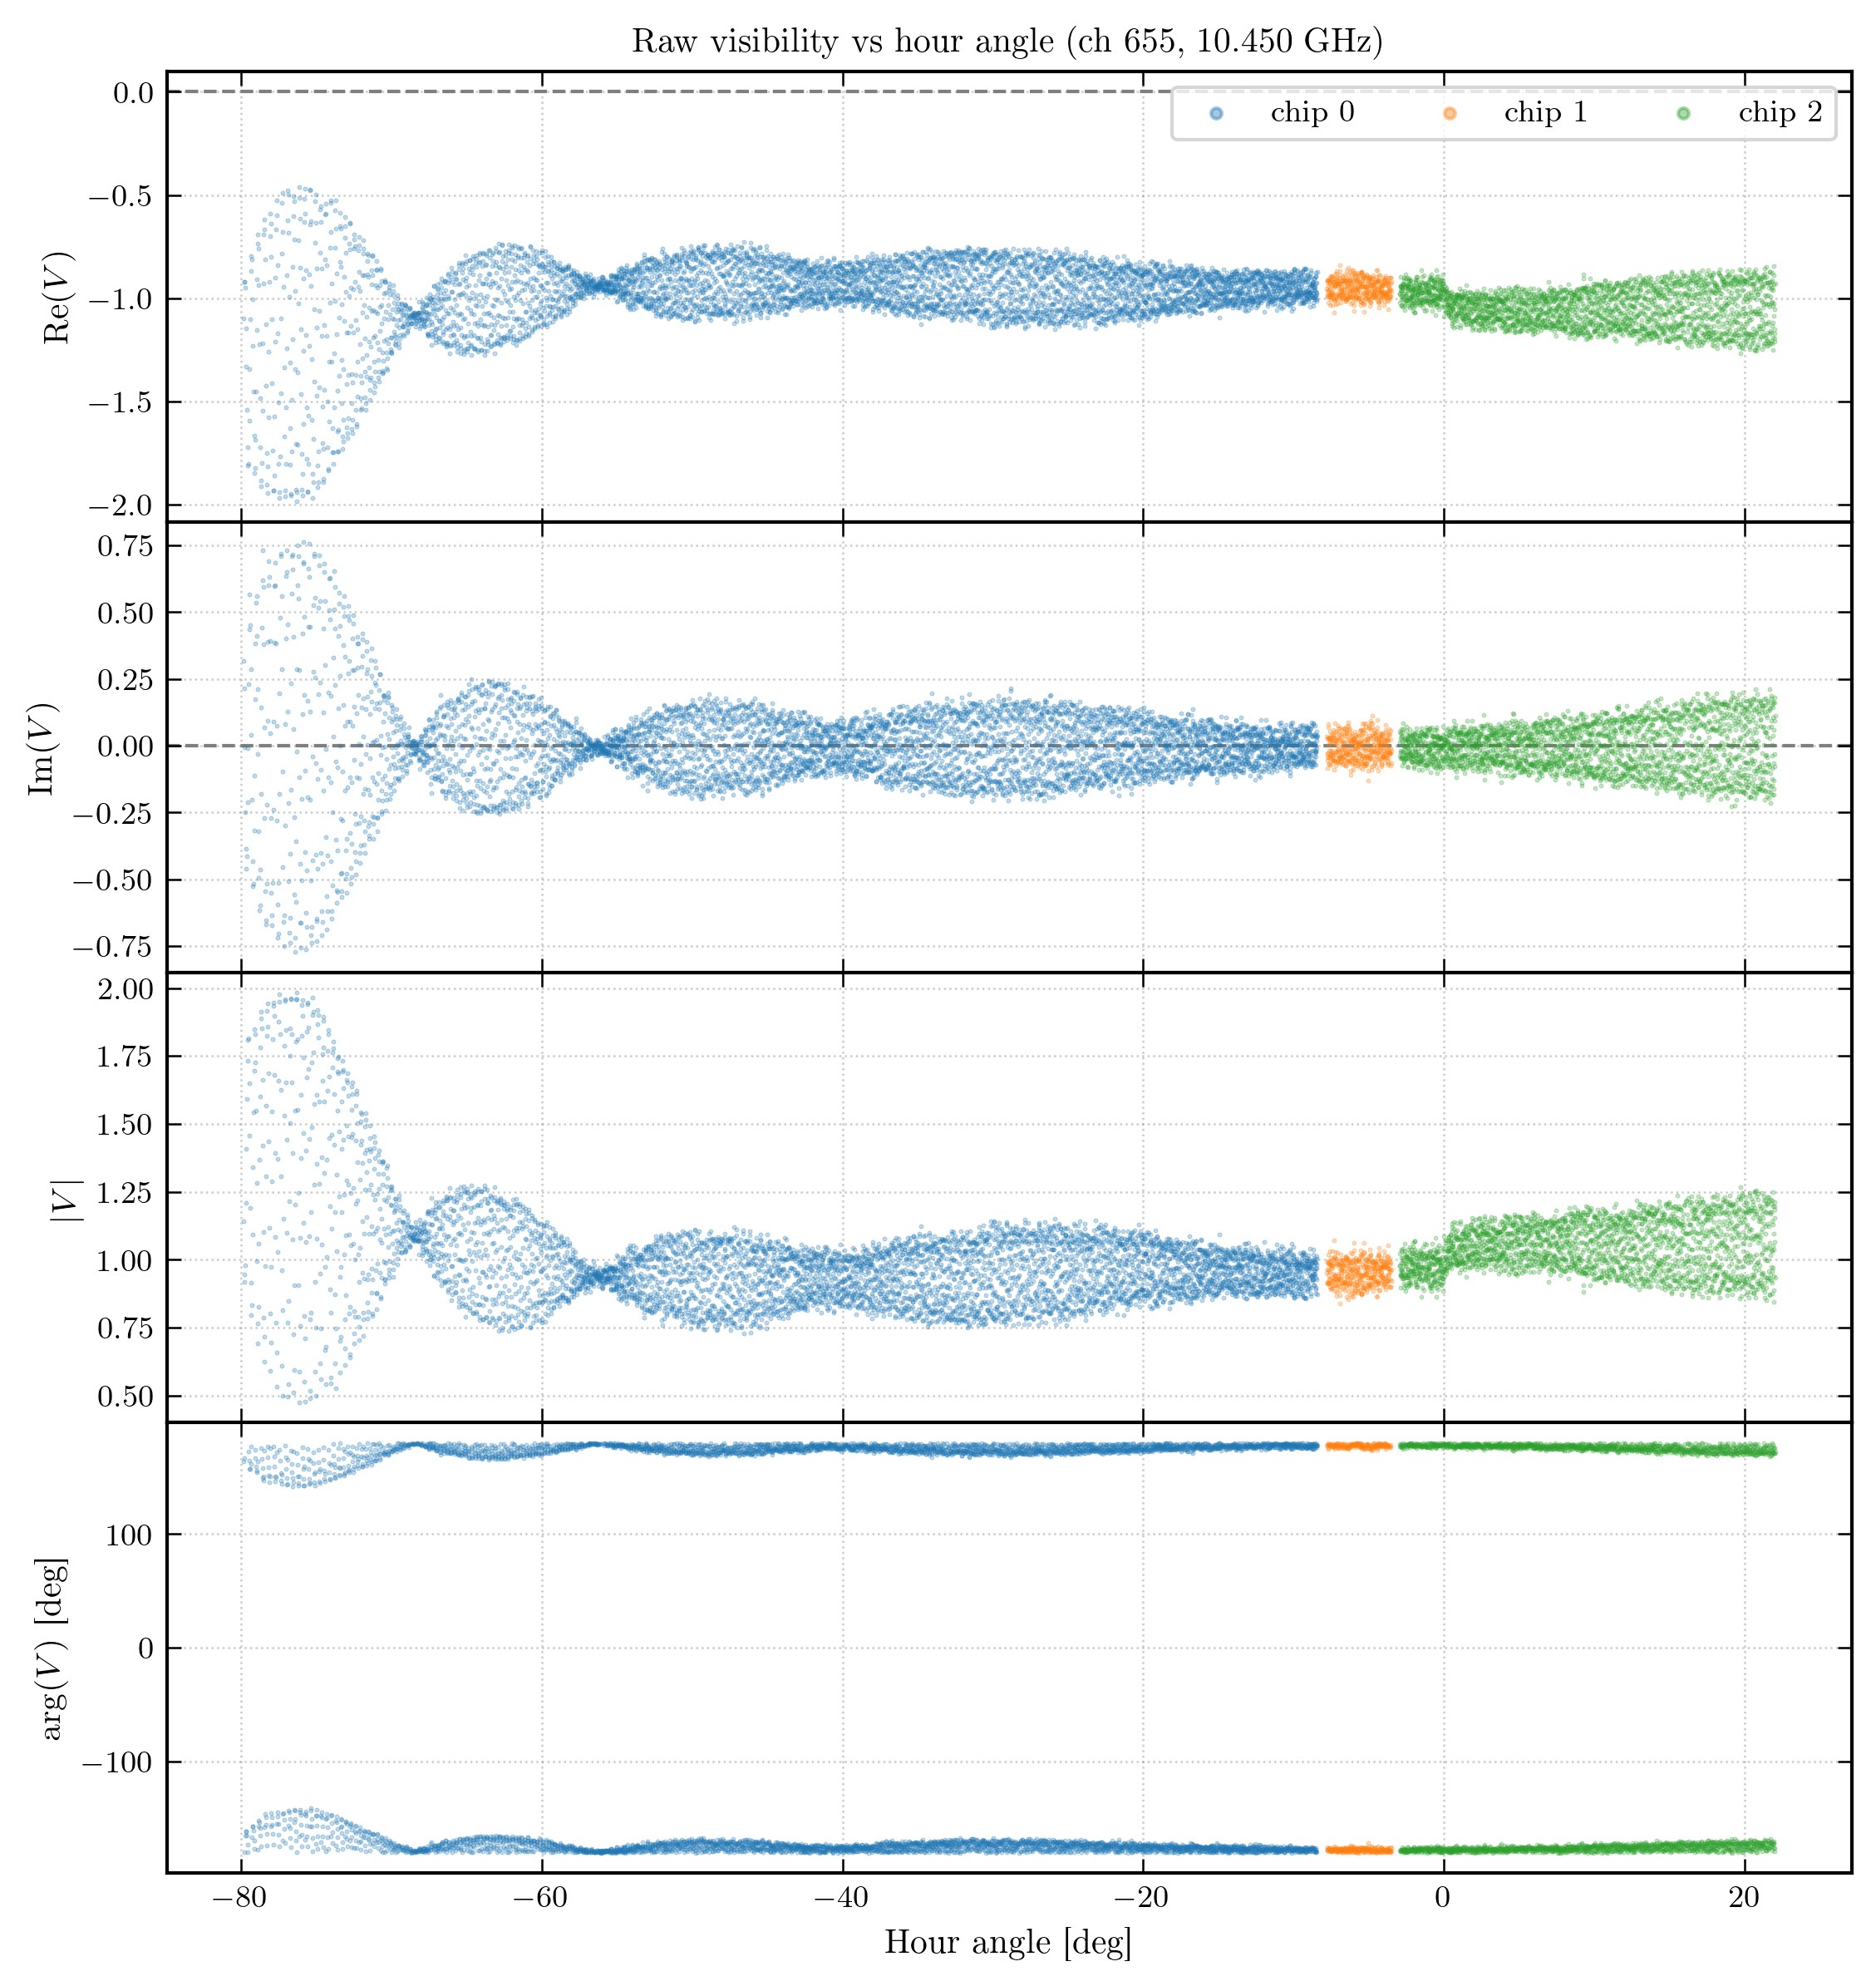

In [3]:
# --- Chip colours ---
CHIP_COLORS = COMPONENT_COLORS[:N_chips]

# --- Representative single channel (mid-band) ---
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
f_mid_ghz = F_SKY_GHZ[k_mid]
vis_ch = corr_raw[:, k_mid]

fig, axes = plot_raw_visibility_4panel(
    ha_deg_arr, vis_ch, chip_slices,
    channel_idx=k_mid, freq_ghz=f_mid_ghz,
)
plt.show()

## Raw amplitude spectrum

Time-averaged amplitude spectrum across the full 250 MHz Nyquist band ($N_{\rm FFT} = 2048$, yielding 1024 output channels of $\Delta\nu = F_S/N_{\rm FFT} \approx 244\;\mathrm{kHz}$, configured per the IF chain documented in [AY121-Lab3]), per chip. This shows the IF bandpass shape, the bad channels (spikes at DC/FPGA harmonics), and the usable analysis band.


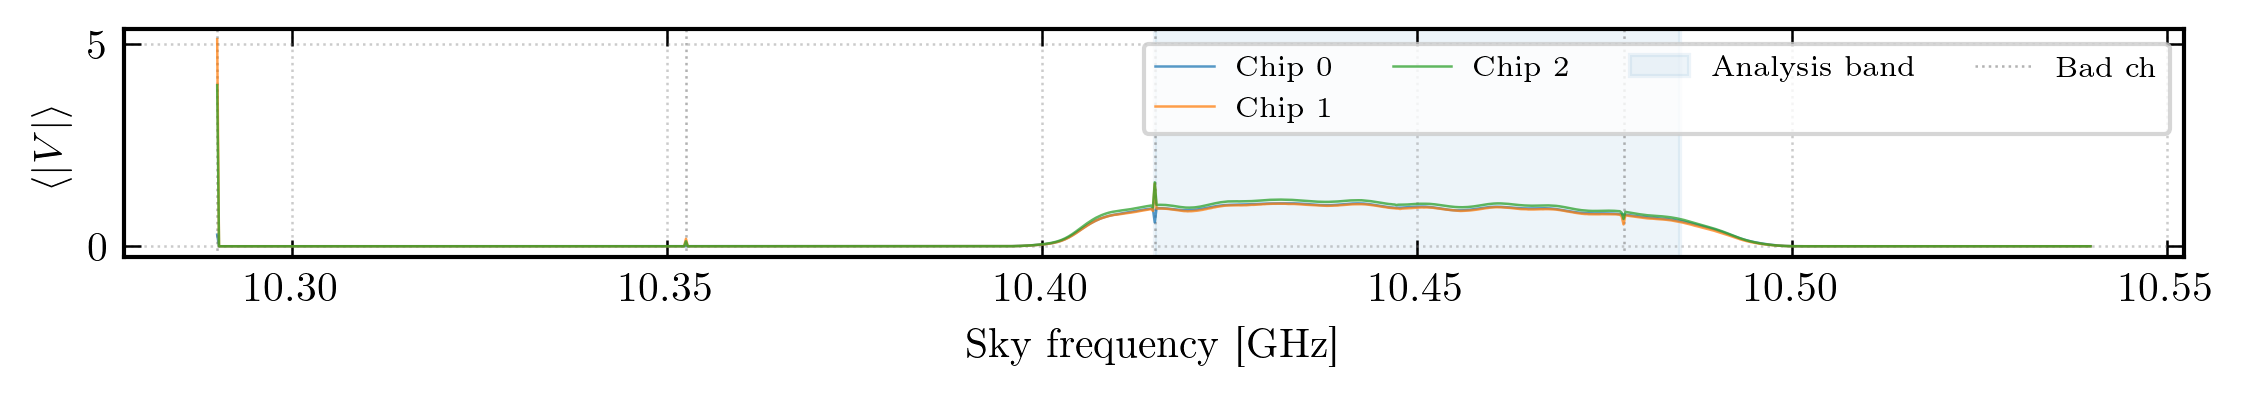

In [4]:
# --- Time-averaged amplitude spectrum per chip ---
fig, ax = plot_amplitude_spectrum(
    F_SKY_GHZ, corr_raw, chip_slices,
    plot_band_ghz=PLOT_BAND_GHZ,
    bad_channels=BAD_CHANNELS,
)
plt.show()

## Observation timeline and cadence

Capture timestamps and inter-capture gaps to visualise the temporal structure of the observation: continuous tracking segments, chip boundaries, and integration cadence.

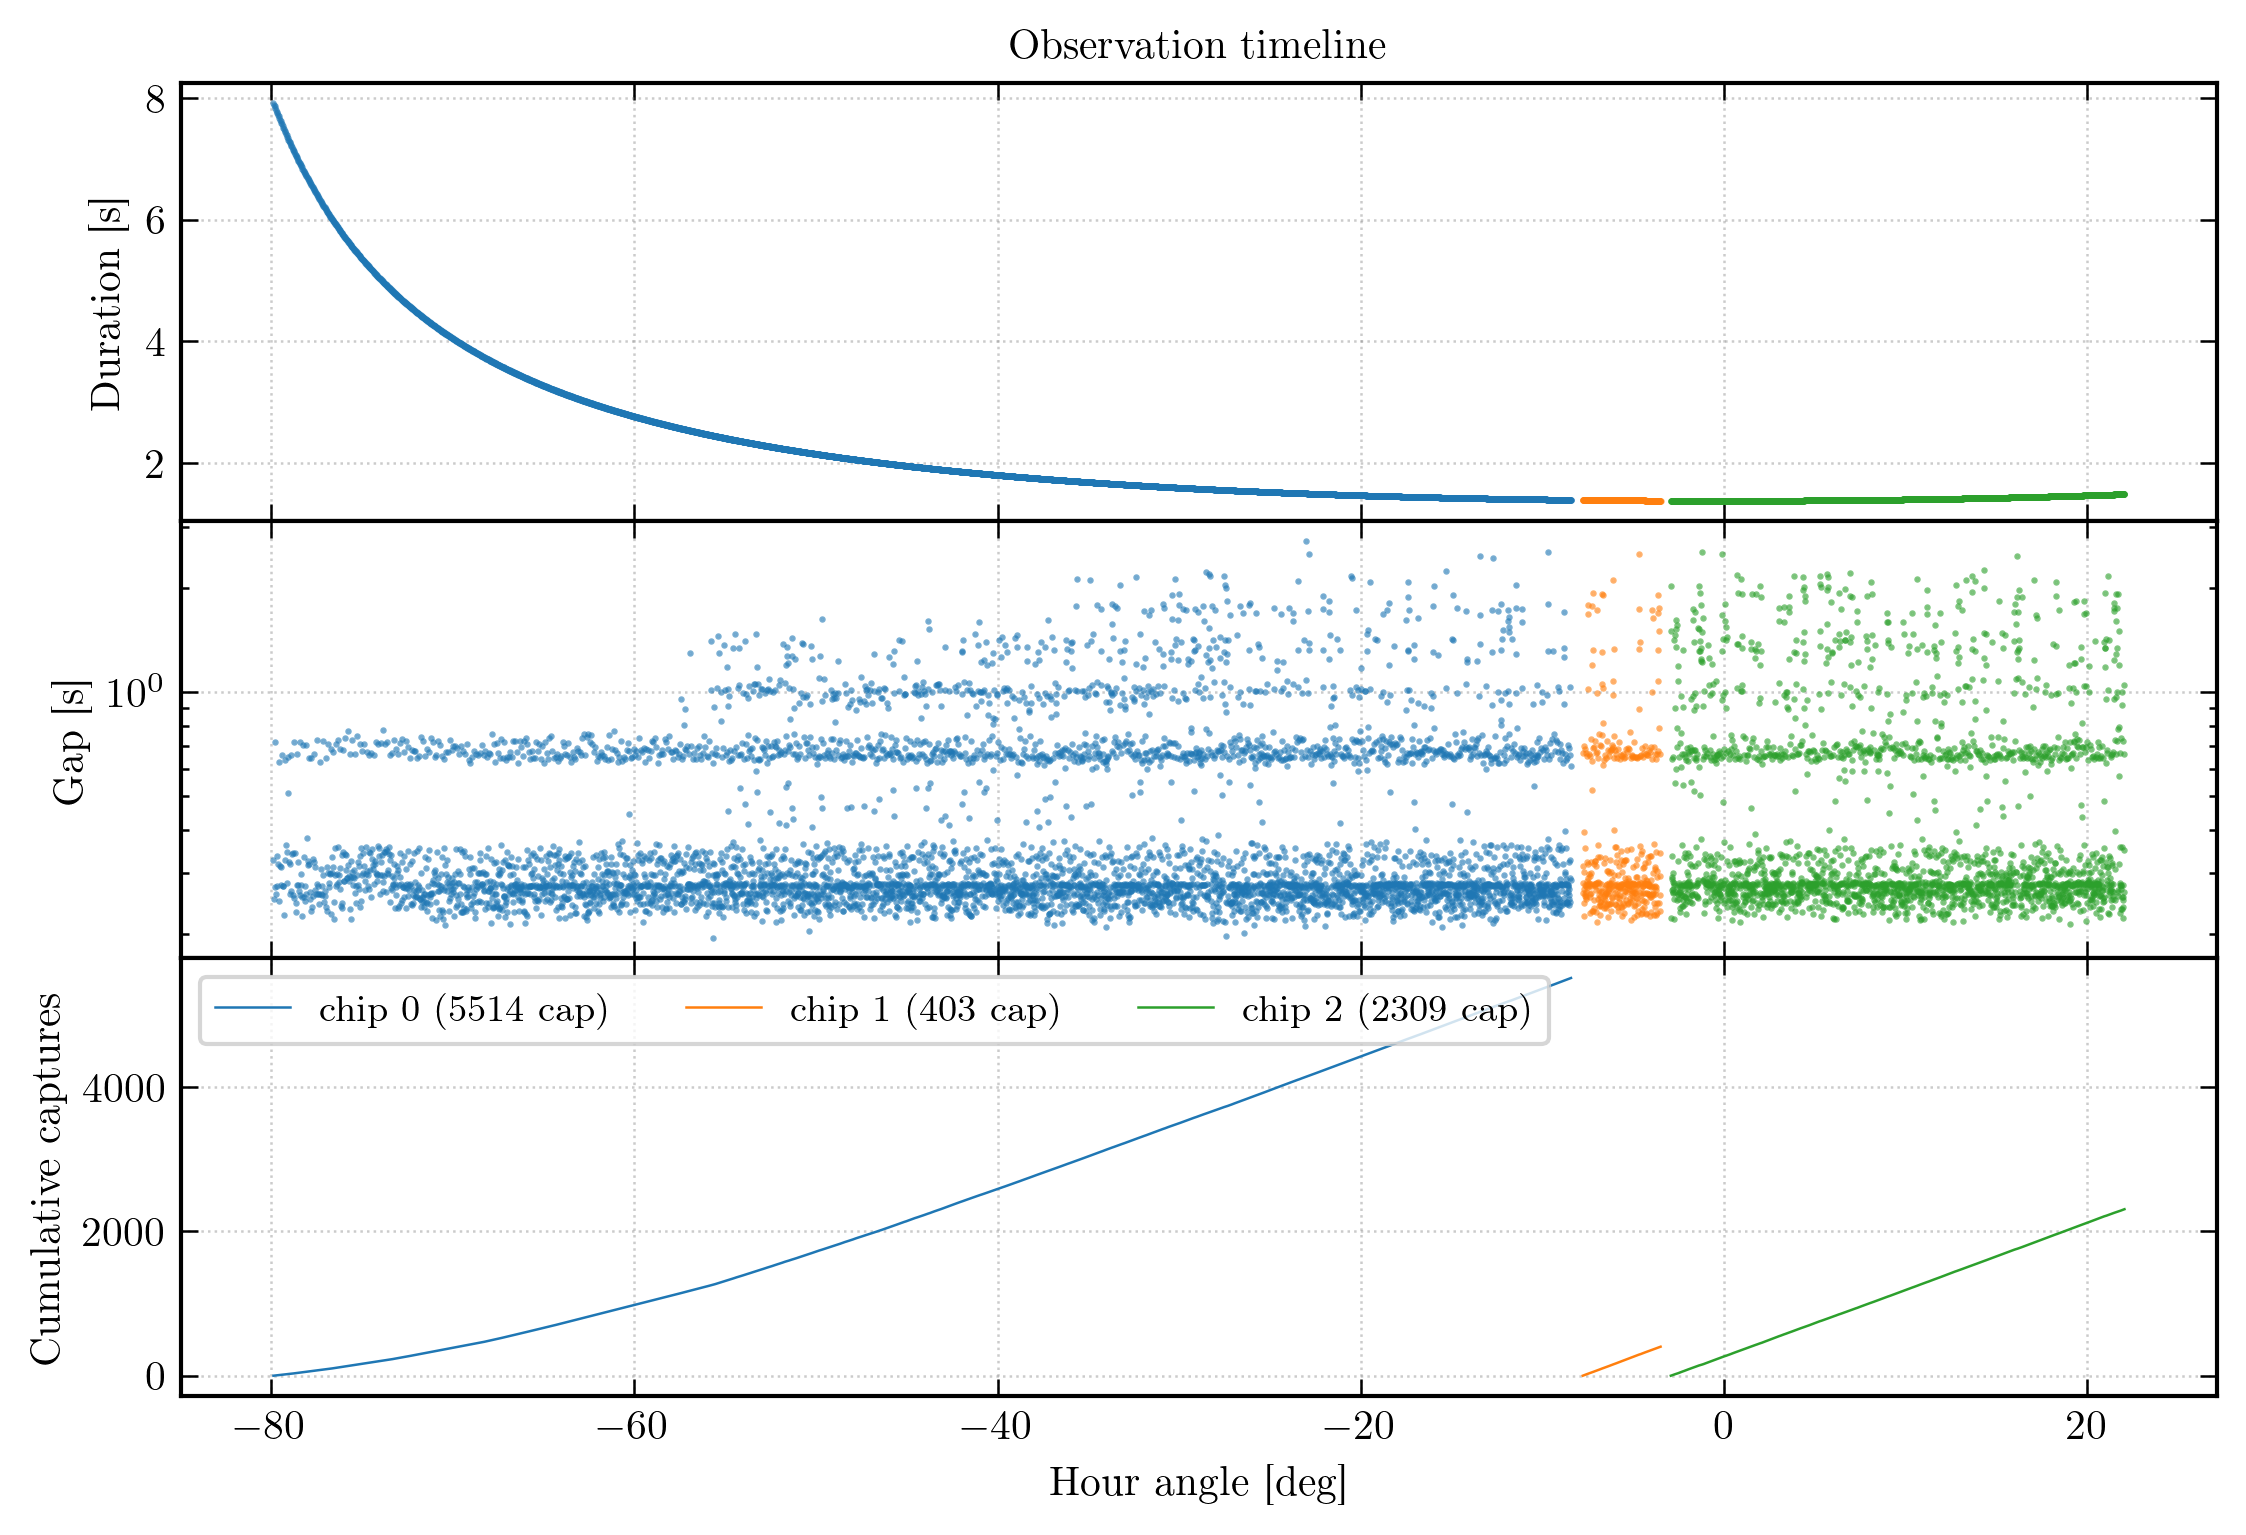

Median gap (end-to-start): 0.28 s
Median integration: 1.51 s


In [5]:
# --- Timeline and cadence ---
unix_mid = captures.unix_mid
duration = captures.duration_sec
# Gap = start of next capture minus end of previous capture (dead time between integrations)
gaps = captures.unix_time_start[1:] - captures.unix_time_end[:-1]

fig, axes = plot_observation_timeline(
    ha_deg_arr, duration, gaps, chip_slices,
)
plt.show()

print(f"Median gap (end-to-start): {np.median(gaps[gaps < 10]):.2f} s")
print(f"Median integration: {np.median(duration):.2f} s")

## Summary statistics, noise estimate, and chip-gain check

The per-chip table below reports captures, JD range, hour-angle range, and solar declination range, along with median band-averaged $|V|$. Two things to look for:

1. **A per-capture noise estimate** $\hat\sigma_V$, computed via temporal differencing: for each frequency channel, $\sigma = \mathrm{std}(\Delta V) / \sqrt{2}$, then averaged across channels. Temporal differencing avoids conflating real spectral structure (bandpass shape, RFI, etc.) with noise, unlike across-channel scatter of $|V|$. (The radiometer-equation context is in §1.7b of the theory notebook; the canonical reference is [R&W] §4.1 or [TMS3] §6.2.)
2. **A chip-to-chip gain check.** The median $|V|$ in the analysis band should be (approximately) the same in all chips, since the source flux and the antenna gains are nominally constant on the timescale of one observation. A jump between chips of more than a few percent indicates an unmodelled gain step (back-end re-tune, attenuator change, gain drift) that — if uncorrected — will look like a real fringe feature in the diameter and sunspot fits and must be flagged. (No published reference quantifies this for the NCH back-end; the value is empirical, and the inflation it introduces in the Part V of nb 05 is bracketed.)

In [6]:
# --- Per-chip summary, noise estimate, and gain check ---
unix_mid = captures.unix_mid
jd_arr = unix_mid / 86_400.0 + 2_440_587.5  # Unix -> JD
sun_dec_arr = chip_data.sun_dec_deg

print(f"{'Chip':>6} {'N_cap':>7} {'JD range':>28} {'HA range [deg]':>20} "
      f"{'Sun dec range [deg]':>22}")
print("-" * 90)
chip_med_amp = []
chip_sigma_V = []
for ci, sl in enumerate(chip_slices):
    n = sl.stop - sl.start
    jd_lo, jd_hi = jd_arr[sl].min(), jd_arr[sl].max()
    ha_lo, ha_hi = ha_deg_arr[sl].min(), ha_deg_arr[sl].max()
    dec_lo, dec_hi = sun_dec_arr[sl].min(), sun_dec_arr[sl].max()
    med_amp = np.nanmedian(np.abs(corr_band[sl]))
    chip_med_amp.append(med_amp)
    # Per-capture noise via temporal differencing: for each channel, the
    # std of the first-difference of V divided by sqrt(2) gives the
    # per-sample noise.  This is preferred over across-channel scatter of
    # |V|, which conflates real spectral structure with noise.
    n_ch = corr_band.shape[1]
    sigma_per_ch = np.nanstd(np.diff(corr_band[sl], axis=0), axis=0) / np.sqrt(2)
    sigma_med = float(np.nanmean(np.abs(sigma_per_ch)))
    chip_sigma_V.append(sigma_med)
    print(f"{ci:>6} {n:>7} {jd_lo:.5f}–{jd_hi:.5f} {ha_lo:>8.1f} to {ha_hi:>6.1f} "
          f"{dec_lo:>9.4f} to {dec_hi:>7.4f}")

# Chip-to-chip gain ratio relative to chip 0
# Note: chip gains computed from median |V| may include a contribution from
# the Bessel envelope variation across the different HA ranges covered by
# each chip. This is a ~few-percent effect that is absorbed into the chip
# gain correction.
chip_med_amp = np.array(chip_med_amp)
chip_gains_measured = chip_med_amp / chip_med_amp[0]   # exported downstream
print("\nChip-to-chip gain ratios (relative to chip 0):")
for ci, r in enumerate(chip_gains_measured):
    flag = "  <-- WARNING: > 3% gain step" if abs(r - 1) > 0.03 else ""
    print(f"  chip {ci}: {r:.4f}{flag}")

# Median per-capture sigma_V across all chips. Notebook 04 and 05 cite this
# as the input per-capture uncertainty on |V|.
SIGMA_V_PER_CAPTURE = float(np.median(chip_sigma_V))

print(f"\nTotal captures: {corr_raw.shape[0]}")
print(f"Frequency channels: {corr_raw.shape[1]} ({F_SKY_GHZ[0]:.3f}-{F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Bad channels: {list(BAD_CHANNELS)}")
print(f"Analysis band: {PLOT_BAND_GHZ[0]:.3f}-{PLOT_BAND_GHZ[1]:.3f} GHz "
      f"({band_mask.sum()} good channels)")
print(f"Per-capture sigma_V (median across chips): {SIGMA_V_PER_CAPTURE:.4g}")
print()
print("The ~10% chip 0 -> chip 2 gain step is the dominant amplitude systematic")
print("for the diameter and sunspot fits. The vector `chip_gains_measured` is")
print("consumed by notebooks 04 and 05 via `apply_chip_gain_correction` to put")
print("all chips on a common amplitude scale before the baseline and diameter")
print("fits are run.")

# Persist the measured values so 04 and 05 pick them up without re-running 02a.
import pickle as _pkl
sidecar = Path("_chip_gain_measured.pkl")
with open(sidecar, "wb") as _f:
    _pkl.dump({
        "chip_gains_measured": chip_gains_measured,
        "sigma_V_per_capture": SIGMA_V_PER_CAPTURE,
        "reference_chip": 0,
        "band_ghz": [float(PLOT_BAND_GHZ[0]), float(PLOT_BAND_GHZ[1])],
    }, _f)
print(f"Wrote calibration sidecar: {sidecar.resolve()}")

  Chip   N_cap                     JD range       HA range [deg]    Sun dec range [deg]
------------------------------------------------------------------------------------------
     0    5514 2461120.12199–2461120.32035    -79.9 to   -8.4   -0.1439 to -0.0655
     1     403 2461120.32215–2461120.33404     -7.8 to   -3.5   -0.0647 to -0.0600
     2    2309 2461120.33561–2461120.40496     -2.9 to   22.0   -0.0594 to -0.0320

Chip-to-chip gain ratios (relative to chip 0):
  chip 0: 1.0000
  chip 1: 1.0102
  chip 2: 1.0991  <-- WARNING: > 3% gain step

Total captures: 8226
Frequency channels: 1024 (10.290-10.540 GHz)
Bad channels: [0, 256, 512, 768]
Analysis band: 10.415-10.485 GHz (285 good channels)
Per-capture sigma_V (median across chips): 0.04992

The ~10% chip 0 -> chip 2 gain step is the dominant amplitude systematic
for the diameter and sunspot fits. The vector `chip_gains_measured` is
consumed by notebooks 04 and 05 via `apply_chip_gain_correction` to put
all chips on a common a